# Model Validation Notebook

Load a saved model from `data/saved_models/` and run validation.

In [8]:
import pandas as pd
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt
import glob
from collections import Counter
from pathlib import Path

# Imports from our project
from src.utils.paths import PROJECT_ROOT, get_data_folder
from src.utils.ontology_utils import load_ontology
from src.train.model import SimpleNN
from src.train.loss import MarginalizationLoss

## 1. Select and Load Model

In [20]:
# List all available models
save_dir = PROJECT_ROOT / "data" / "saved_models"
model_files = sorted(glob.glob(str(save_dir / "blood_cell_model_*.pt")))

print("Available models:")
for i, model_file in enumerate(model_files):
    model_name = model_file.split('/')[-1]
    print(f"  [{i}] {model_name}")

if not model_files:
    print("\n⚠️  No saved models found in data/saved_models/")
    print("   Please train a model first using train_blood_cell.ipynb")
else:
    # Auto-select the latest model (or change index to select different model)
    model_index = -2  # -1 = latest, 0 = oldest, etc.
    model_path = model_files[model_index]
    print(f"\n✓ Selected: {model_path.split('/')[-1]}")

Available models:
  [0] blood_cell_model_2025-10-31_07-02-10.pt
  [1] blood_cell_model_2025-10-31_07-02-10_weights_only.pt
  [2] blood_cell_model_2025-11-01_00-10-25.pt
  [3] blood_cell_model_2025-11-01_00-10-25_weights_only.pt

✓ Selected: blood_cell_model_2025-11-01_00-10-25.pt


In [21]:
# Load checkpoint
print(f"Loading checkpoint from: {model_path}")
checkpoint = torch.load(model_path, map_location='cpu')

# Print checkpoint info
print("\n" + "="*80)
print("CHECKPOINT INFORMATION")
print("="*80)
print(f"Model architecture: SimpleNN()")
print(f"Training epochs: {checkpoint['epoch']}")
print(f"Total batches processed: {checkpoint['total_batches_processed']:,}")
print(f"Final training loss: {checkpoint['batch_loss_history'][-1]:.4f}")
print(f"Trained on {checkpoint['num_gpus']} GPU(s)")
print(f"Total training time: {sum(checkpoint['epoch_times'])/3600:.2f} hours")
print("="*80 + "\n")

# Extract key variables
DATE = checkpoint['date_preprocessed']
input_dim = checkpoint['input_dim']
output_dim = checkpoint['output_dim']

Loading checkpoint from: /home/jingqiao/real_McCell/data/saved_models/blood_cell_model_2025-11-01_00-10-25.pt

CHECKPOINT INFORMATION
Model architecture: SimpleNN()
Training epochs: 5
Total batches processed: 98,325
Final training loss: 0.1807
Trained on 6 GPU(s)
Total training time: 10.05 hours



## 2. Load Preprocessed Data

In [22]:
# Load data from the same date as the model was trained on
PROCESSED_DATA_DIR = get_data_folder(DATE)
print(f"Loading data from: {PROCESSED_DATA_DIR} for date {DATE}")

# Load the ontology
cl = load_ontology()

# Load DataFrames
marginalization_df = pd.read_csv(PROCESSED_DATA_DIR / f"{DATE}_marginalization_df.csv", index_col=0)
parent_child_df = pd.read_csv(PROCESSED_DATA_DIR / f"{DATE}_parent_child_df.csv", index_col=0)
exclusion_df = pd.read_csv(PROCESSED_DATA_DIR / f"{DATE}_exclusion_df.csv", index_col=0)

# Load mapping_dict
mapping_dict_df = pd.read_csv(PROCESSED_DATA_DIR / f"{DATE}_mapping_dict_df.csv", index_col=0)
mapping_dict = pd.Series(mapping_dict_df.iloc[:, 0].values, index=mapping_dict_df.index).to_dict()

# Load leaf and internal values
with open(PROCESSED_DATA_DIR / f"{DATE}_leaf_values.pkl", "rb") as fp:
    leaf_values = pickle.load(fp)
with open(PROCESSED_DATA_DIR / f"{DATE}_internal_values.pkl", "rb") as fp:
    internal_values = pickle.load(fp)

print("\nAll data artifacts loaded successfully.")
print(f"Loaded {len(mapping_dict)} cell types.")
print(f"  - {len(leaf_values)} leaf nodes")
print(f"  - {len(internal_values)} internal nodes")

Loading data from: /home/jingqiao/real_McCell/data/processed/10-24 for date 2025-10-24
Loading cached ontology from /home/jingqiao/real_McCell/data/processed/ontology.pkl...
Ontology loaded successfully.

All data artifacts loaded successfully.
Loaded 80 cell types.
  - 23 leaf nodes
  - 57 internal nodes


## 3. Initialize Model and Load Weights

In [23]:
# Setup device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create model architecture
validation_model = SimpleNN(input_dim=input_dim, output_dim=output_dim)

# Handle DataParallel if model was trained on multiple GPUs
num_gpus = torch.cuda.device_count()
if num_gpus > 1:
    validation_model = torch.nn.DataParallel(validation_model)
    validation_model.module.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded DataParallel model ({num_gpus} GPUs available)")
else:
    validation_model.load_state_dict(checkpoint['model_state_dict'])
    print("Loaded model (single GPU)")

validation_model = validation_model.to(device)
validation_model.eval()

print("Model loaded successfully and set to evaluation mode.")

# Initialize loss function
loss_fn = MarginalizationLoss(
    marginalization_df=marginalization_df,
    parent_child_df=parent_child_df,
    exclusion_df=exclusion_df,
    leaf_values=leaf_values,
    internal_values=internal_values,
    mapping_dict=mapping_dict,
    device=device
)
print("Loss function initialized.")

Using device: cuda:0
Loaded DataParallel model (2 GPUs available)
Model loaded successfully and set to evaluation mode.
Loss function initialized.


## 4. Create Validation DataLoader

In [24]:
import cellxgene_census
import tiledbsoma as soma
from tiledbsoma_ml import ExperimentDataset, experiment_dataloader

# Get all cell types
all_cell_values = list(mapping_dict.keys())

# Load gene list from BioMart
print("Loading protein-coding genes from BioMart...")
biomart_path = PROJECT_ROOT / "hpc_workaround/data/mart_export.txt"
biomart = pd.read_csv(biomart_path)
coding_only = biomart[biomart['Gene type'] == 'protein_coding']
gene_list = coding_only['Gene stable ID'].tolist()
print(f"Loaded {len(gene_list)} protein-coding genes")

# Create filter strings
var_value_filter = f"feature_id in {gene_list}"
obs_value_filter = f'assay == "10x 3\' v3" and is_primary_data == True and cell_type_ontology_term_id in {all_cell_values}'

# Open SOMA database
soma_uri = "/scratch/sigbio_project_root/sigbio_project25/jingqiao/mccell-single/soma_db_homo_sapiens"
print(f"\nOpening local SOMA database at: {soma_uri}")
experiment = soma.open(soma_uri, mode="r")

# Create validation dataset
with experiment.axis_query(
    measurement_name="RNA",
    obs_query=soma.AxisQuery(value_filter=obs_value_filter),
    var_query=soma.AxisQuery(value_filter=var_value_filter),
) as query:
    experiment_dataset = ExperimentDataset(
        query,
        obs_column_names=["cell_type_ontology_term_id"],
        layer_name="raw",
        batch_size=256,
        shuffle=True,
        seed=999  # Different seed for validation
    )
    
    # Use only validation split (20%)
    _, val_dataset = experiment_dataset.random_split(0.8, 0.2, seed=42)
    
    print(f'\nValidation set size: {len(val_dataset)}')
    print(f'Validation dataset shape: {val_dataset.shape}')

val_dataloader = experiment_dataloader(val_dataset)
print("Validation dataloader ready.")

Loading protein-coding genes from BioMart...
Loaded 23262 protein-coding genes

Opening local SOMA database at: /scratch/sigbio_project_root/sigbio_project25/jingqiao/mccell-single/soma_db_homo_sapiens

Validation set size: 4917
Validation dataset shape: (4917, 20060)
Validation dataloader ready.


## 5. Run Validation (Leaf Nodes Only)

In [25]:
print("="*80)
print("RUNNING VALIDATION (LEAF NODES ONLY)")
print("="*80)

val_batches = 50  # Number of validation batches to process

val_total_losses = []
val_leaf_losses = []
val_parent_losses = []
all_predictions = []
all_labels = []

leaf_indices_set = {mapping_dict[cid] for cid in leaf_values}
total_samples = 0
leaf_samples = 0

with torch.no_grad():
    for i, (X_batch, obs_batch) in enumerate(val_dataloader):
        if i >= val_batches:
            break

        # Data preparation
        X_batch = torch.from_numpy(X_batch).float()
        X_batch = torch.log1p(X_batch)
        X_batch = X_batch.to(device)

        label_strings = obs_batch["cell_type_ontology_term_id"]
        y_batch = torch.tensor([mapping_dict[term] for term in label_strings],
                              device=device, dtype=torch.long)

        total_samples += len(y_batch)

        # FILTER: Only keep samples with LEAF node labels
        is_leaf = torch.tensor([y.item() in leaf_indices_set for y in y_batch], device=device)

        if is_leaf.sum() == 0:
            continue  # Skip batches with no leaf samples

        X_batch_leaf = X_batch[is_leaf]
        y_batch_leaf = y_batch[is_leaf]
        leaf_samples += len(y_batch_leaf)

        # Forward pass
        outputs = validation_model(X_batch_leaf)
        total_loss, loss_leafs, loss_parents = loss_fn(outputs, y_batch_leaf)

        val_total_losses.append(total_loss.item())
        val_leaf_losses.append(loss_leafs.item())
        val_parent_losses.append(loss_parents.item())

        # Get predictions (argmax of logits)
        predictions = torch.argmax(outputs, dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch_leaf.cpu().numpy())

# Calculate metrics
avg_val_loss = np.mean(val_total_losses)
avg_leaf_loss = np.mean(val_leaf_losses)
avg_parent_loss = np.mean(val_parent_losses)

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
accuracy = (all_predictions == all_labels).mean()

print(f"\nValidation Results (LEAF-LABELED SAMPLES ONLY):")
print(f"  Total samples processed: {total_samples:,}")
print(f"  Leaf-labeled samples: {leaf_samples:,} ({leaf_samples/total_samples*100:.1f}%)")
print(f"  Internal-labeled samples (skipped): {total_samples - leaf_samples:,}")
print(f"\n  Average Total Loss: {avg_val_loss:.4f}")
print(f"  Average Leaf Loss:  {avg_leaf_loss:.4f}")
print(f"  Average Parent Loss: {avg_parent_loss:.4f}")
print(f"  Leaf Accuracy: {accuracy*100:.2f}%")
print("\n" + "="*80)

RUNNING VALIDATION (LEAF NODES ONLY)


/home/jingqiao/real_McCell/.venv/lib64/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return F.linear(input, self.weight, self.bias)



Validation Results (LEAF-LABELED SAMPLES ONLY):
  Total samples processed: 12,800
  Leaf-labeled samples: 1,224 (9.6%)
  Internal-labeled samples (skipped): 11,576

  Average Total Loss: 3.1460
  Average Leaf Loss:  3.1388
  Average Parent Loss: 0.0072
  Leaf Accuracy: 92.81%



## 6. Per-Class Accuracy

In [26]:
# Create reverse mapping (index -> CL ID)
reverse_mapping = {v: k for k, v in mapping_dict.items()}

# Per-class accuracy
unique_labels = np.unique(all_labels)
per_class_accuracy = {}

print("\n" + "="*80)
print("PER-CLASS ACCURACY (LEAF NODES)")
print("="*80)
print(f"{'Cell Type':<50} {'Count':<8} {'Accuracy':<10}")
print("-" * 80)

for label_idx in sorted(unique_labels):
    mask = all_labels == label_idx
    class_acc = (all_predictions[mask] == label_idx).mean()
    count = mask.sum()
    
    cl_id = reverse_mapping[label_idx]
    cell_name = cl[cl_id].name
    per_class_accuracy[cl_id] = class_acc
    
    print(f"{cell_name:<50} {count:<8} {class_acc*100:>6.2f}%")

print("="*80 + "\n")


PER-CLASS ACCURACY (LEAF NODES)
Cell Type                                          Count    Accuracy  
--------------------------------------------------------------------------------
platelet                                           31       100.00%
naive thymus-derived CD4-positive, alpha-beta T cell 216       91.20%
naive thymus-derived CD8-positive, alpha-beta T cell 87        94.25%
central memory CD4-positive, alpha-beta T cell     107       82.24%
effector memory CD4-positive, alpha-beta T cell    62        72.58%
cytotoxic T cell                                   25        80.00%
helper T cell                                      72        97.22%
effector memory CD8-positive, alpha-beta T cell    55        94.55%
CD16-negative, CD56-bright natural killer cell, human 15        93.33%
CD16-positive, CD56-dim natural killer cell, human 49       100.00%
mucosal invariant T cell                           12        83.33%
IgA plasma cell                                    19       

## 7. Confusion Matrix

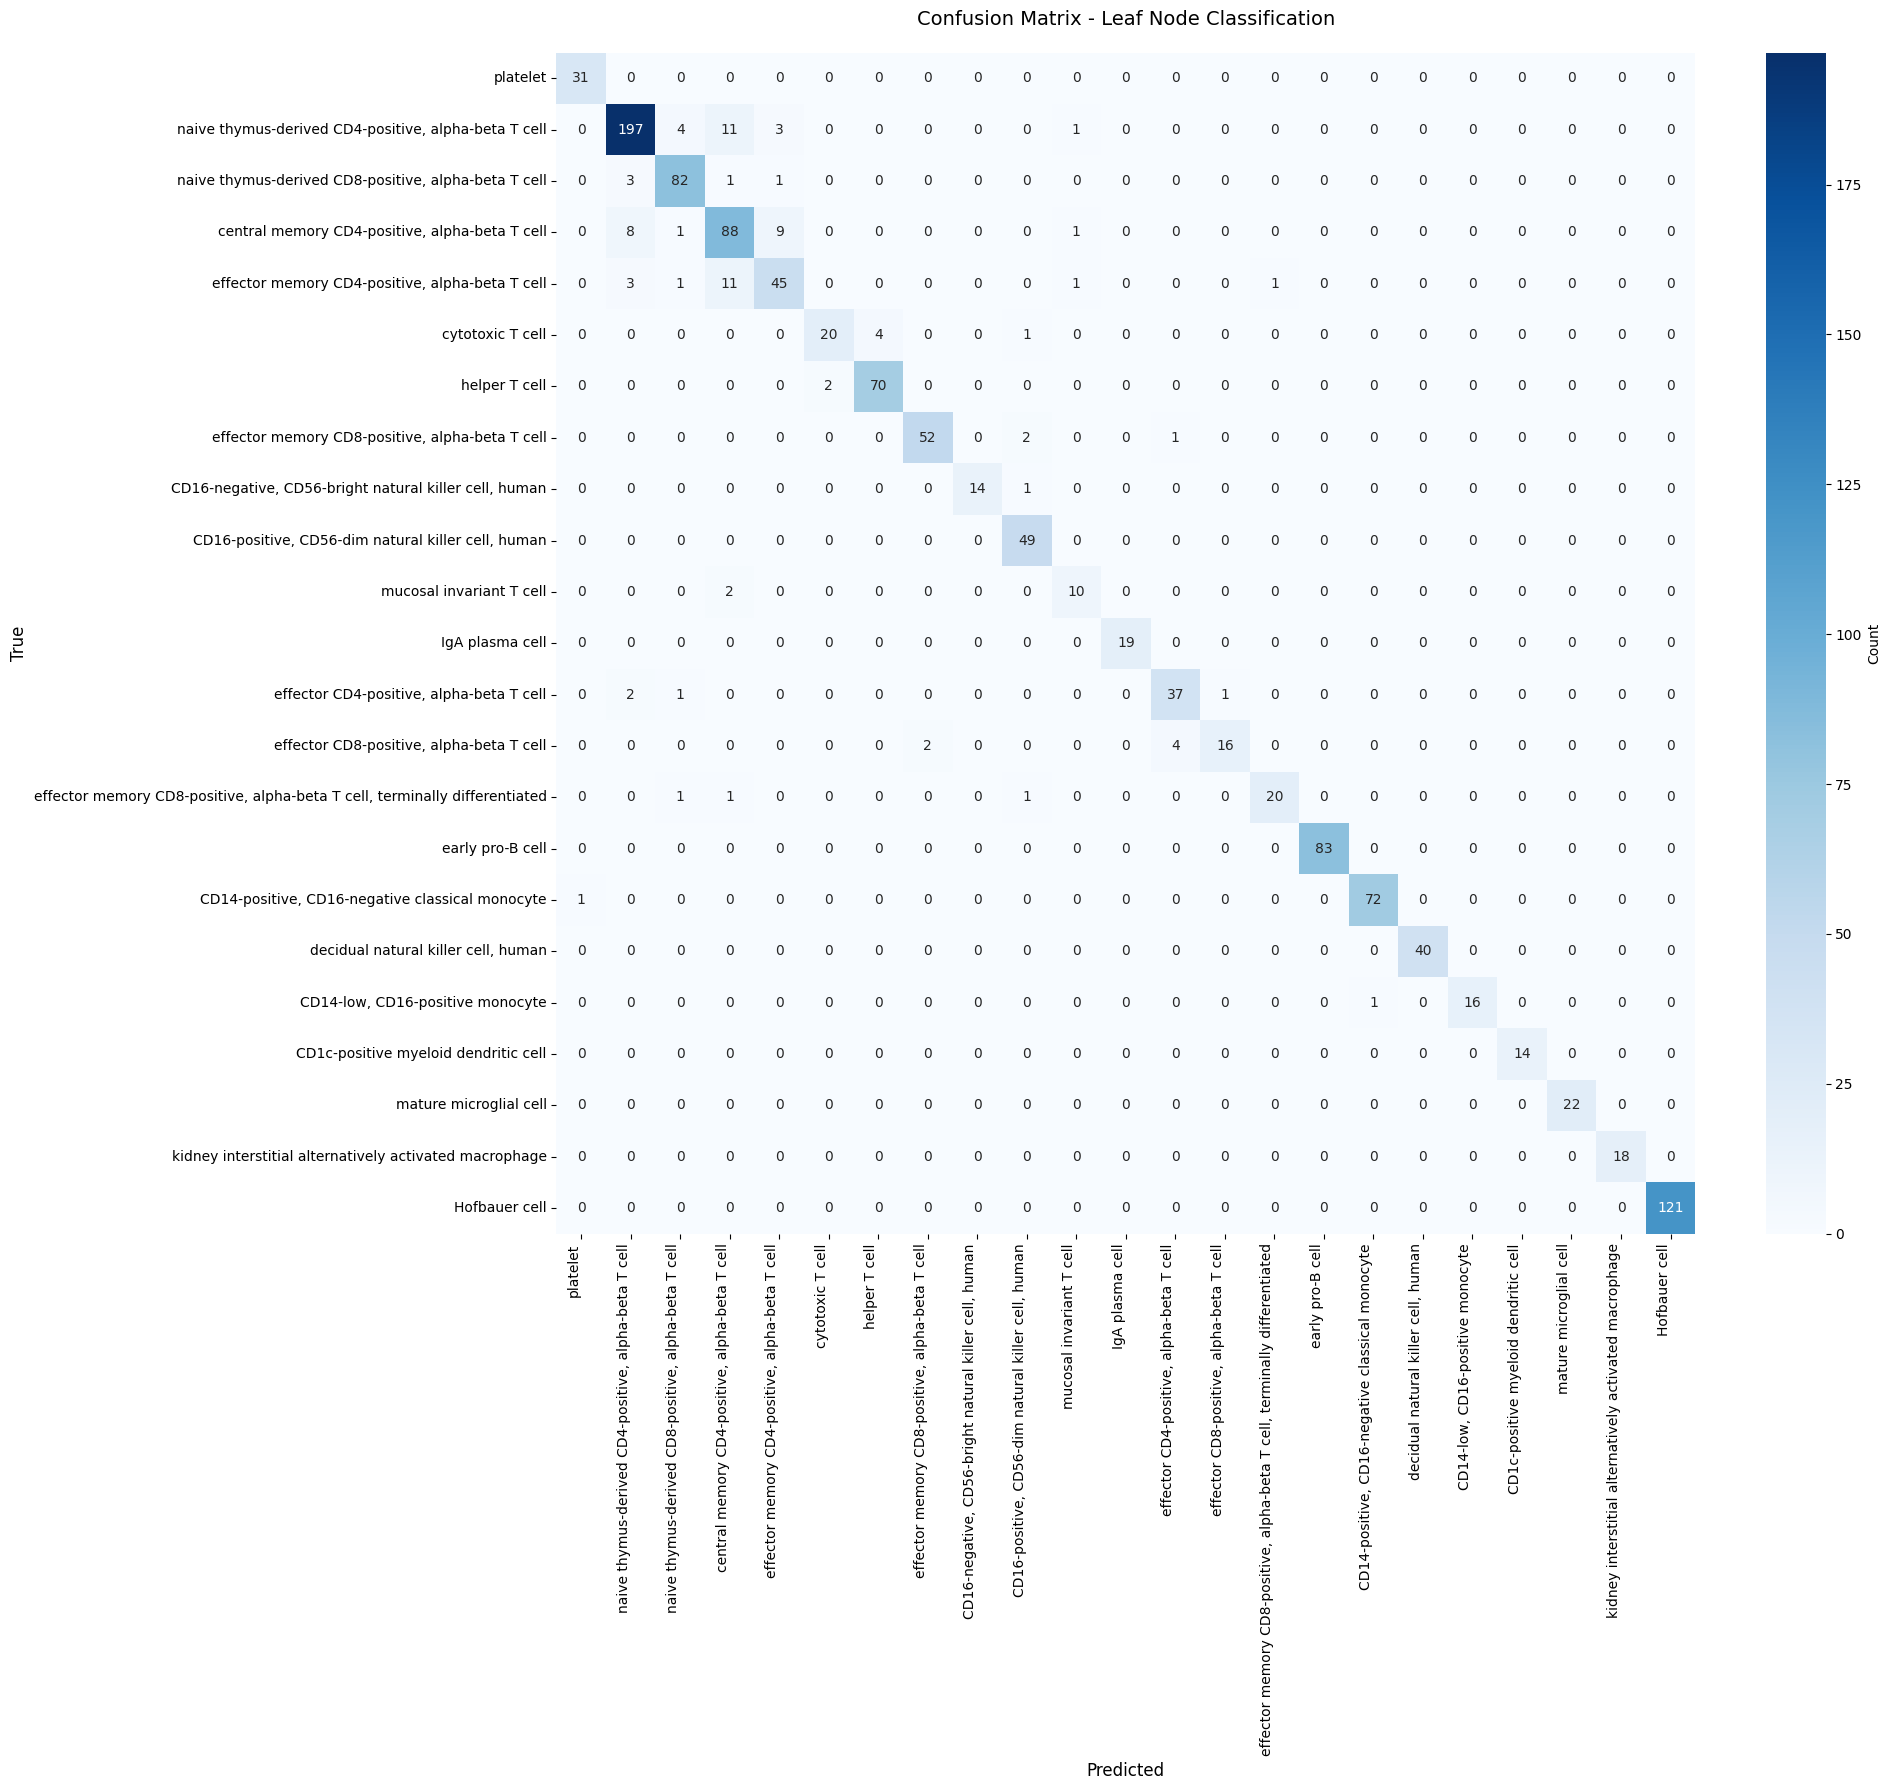

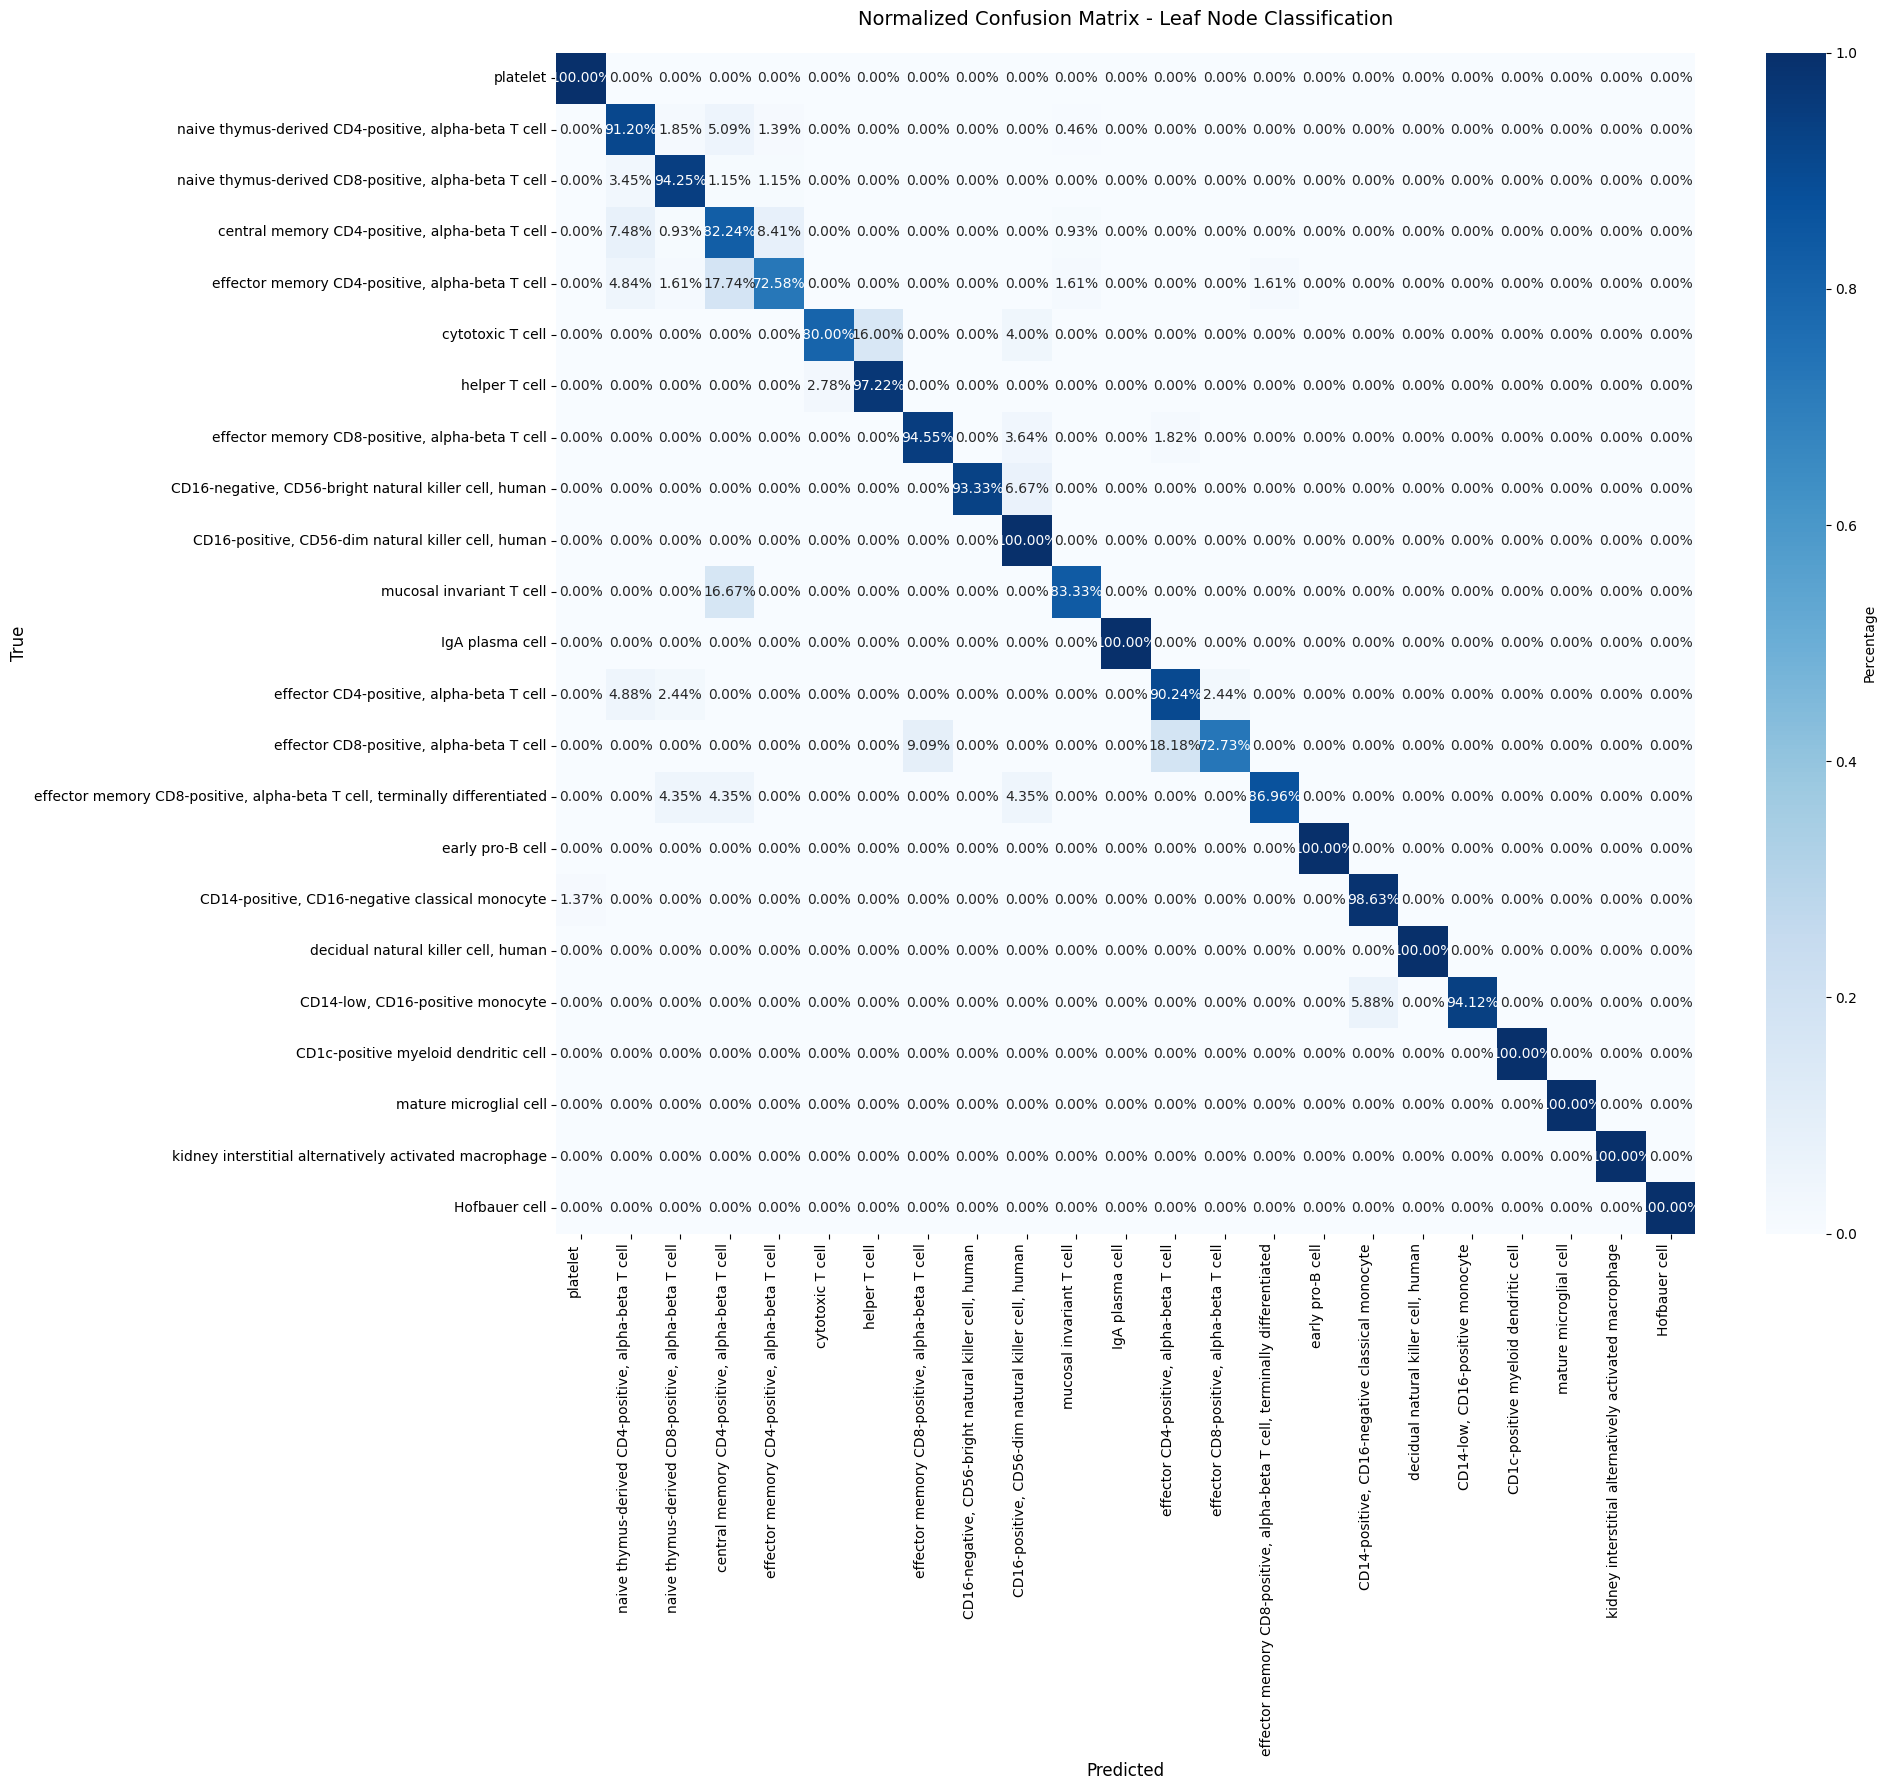

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Get cell type names for labels
unique_labels_sorted = sorted(unique_labels)
label_names = [cl[reverse_mapping[idx]].name for idx in unique_labels_sorted]

# Plot confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix - Leaf Node Classification', fontsize=14, pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(20, 18))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            cbar_kws={'label': 'Percentage'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Normalized Confusion Matrix - Leaf Node Classification', fontsize=14, pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Training History

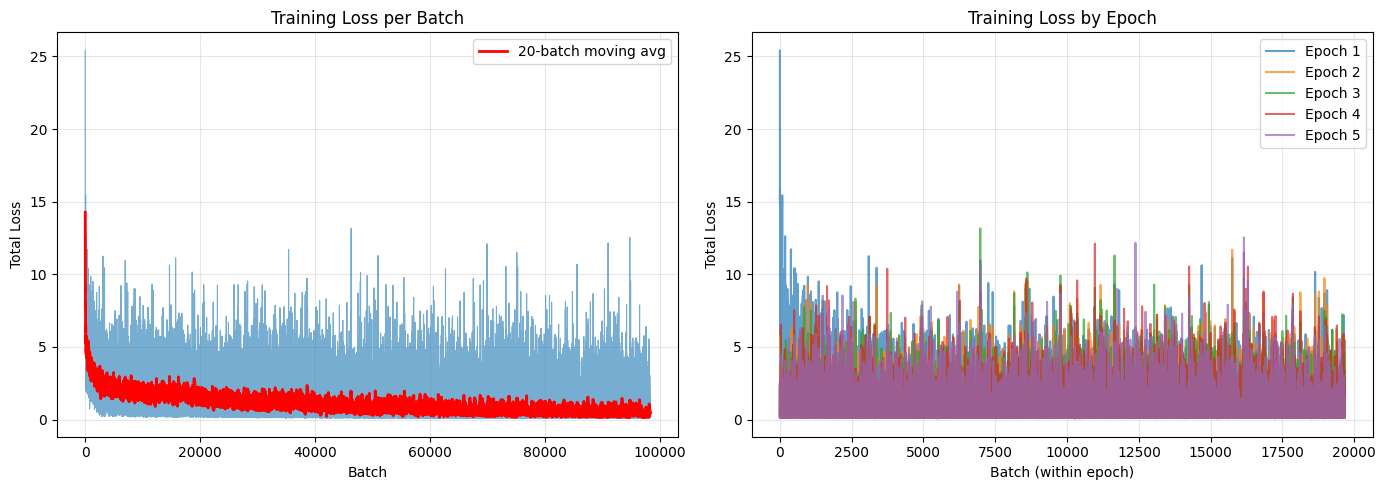


Training Summary:
  Initial loss: 25.3924
  Final loss: 0.1807
  Loss reduction: 99.3%


In [28]:
# Plot training loss from checkpoint
batch_loss_history = checkpoint['batch_loss_history']
num_epochs = checkpoint['epoch']
batches_per_epoch = len(batch_loss_history) // num_epochs

plt.figure(figsize=(14, 5))

# Overall training loss
plt.subplot(1, 2, 1)
plt.plot(batch_loss_history, alpha=0.6, linewidth=0.8)
plt.xlabel('Batch')
plt.ylabel('Total Loss')
plt.title('Training Loss per Batch')
plt.grid(True, alpha=0.3)

# Moving average
window_size = 20
if len(batch_loss_history) >= window_size:
    moving_avg = np.convolve(batch_loss_history, np.ones(window_size)/window_size, mode='valid')
    plt.plot(range(window_size-1, len(batch_loss_history)), moving_avg, 
             color='red', linewidth=2, label=f'{window_size}-batch moving avg')
    plt.legend()

# Loss by epoch
plt.subplot(1, 2, 2)
if num_epochs > 1:
    epoch_losses = [batch_loss_history[i*batches_per_epoch:(i+1)*batches_per_epoch] 
                   for i in range(num_epochs)]
    for i, losses in enumerate(epoch_losses):
        plt.plot(losses, label=f'Epoch {i+1}', alpha=0.7)
    plt.xlabel('Batch (within epoch)')
    plt.ylabel('Total Loss')
    plt.title('Training Loss by Epoch')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining Summary:")
print(f"  Initial loss: {batch_loss_history[0]:.4f}")
print(f"  Final loss: {batch_loss_history[-1]:.4f}")
print(f"  Loss reduction: {(1 - batch_loss_history[-1]/batch_loss_history[0])*100:.1f}%")

## 9. Top Misclassifications

In [29]:
# Find most common misclassifications
print("\n" + "="*80)
print("TOP 10 MISCLASSIFICATIONS")
print("="*80)

misclassifications = []
for true_label, pred_label in zip(all_labels, all_predictions):
    if true_label != pred_label:
        misclassifications.append((true_label, pred_label))

misclass_counts = Counter(misclassifications)

print(f"\nTotal misclassifications: {len(misclassifications):,} / {len(all_labels):,} ({len(misclassifications)/len(all_labels)*100:.2f}%)")
print(f"\nTop 10 most common mistakes:")
print(f"{'True Cell Type':<40} {'→':<3} {'Predicted Cell Type':<40} {'Count':<8}")
print("-" * 100)

for (true_idx, pred_idx), count in misclass_counts.most_common(10):
    true_name = cl[reverse_mapping[true_idx]].name
    pred_name = cl[reverse_mapping[pred_idx]].name
    print(f"{true_name:<40} {'→':<3} {pred_name:<40} {count:<8}")

print("="*80 + "\n")


TOP 10 MISCLASSIFICATIONS

Total misclassifications: 88 / 1,224 (7.19%)

Top 10 most common mistakes:
True Cell Type                           →   Predicted Cell Type                      Count   
----------------------------------------------------------------------------------------------------
naive thymus-derived CD4-positive, alpha-beta T cell →   central memory CD4-positive, alpha-beta T cell 11      
effector memory CD4-positive, alpha-beta T cell →   central memory CD4-positive, alpha-beta T cell 11      
central memory CD4-positive, alpha-beta T cell →   effector memory CD4-positive, alpha-beta T cell 9       
central memory CD4-positive, alpha-beta T cell →   naive thymus-derived CD4-positive, alpha-beta T cell 8       
naive thymus-derived CD4-positive, alpha-beta T cell →   naive thymus-derived CD8-positive, alpha-beta T cell 4       
cytotoxic T cell                         →   helper T cell                            4       
effector CD8-positive, alpha-beta T cell →   

## 10. Summary Report

In [30]:
print("\n" + "="*80)
print("VALIDATION SUMMARY REPORT")
print("="*80)
print(f"\nModel: {model_path.split('/')[-1]}")
print(f"Data Date: {DATE}")
print(f"Architecture: SimpleNN({input_dim} → {output_dim})")
print(f"\nTraining Information:")
print(f"  Epochs: {checkpoint['epoch']}")
print(f"  Total batches: {checkpoint['total_batches_processed']:,}")
print(f"  Final training loss: {checkpoint['batch_loss_history'][-1]:.4f}")
print(f"  Total training time: {sum(checkpoint['epoch_times'])/3600:.2f} hours")
print(f"\nValidation Results (Leaf Nodes Only):")
print(f"  Samples evaluated: {leaf_samples:,}")
print(f"  Average loss: {avg_val_loss:.4f}")
print(f"  Leaf accuracy: {accuracy*100:.2f}%")
print(f"  Unique leaf types: {len(unique_labels)}")
print(f"\nBest performing classes (top 5):")
sorted_classes = sorted(per_class_accuracy.items(), key=lambda x: x[1], reverse=True)
for cl_id, acc in sorted_classes[:5]:
    print(f"  {cl[cl_id].name}: {acc*100:.2f}%")
print(f"\nWorst performing classes (bottom 5):")
for cl_id, acc in sorted_classes[-5:]:
    print(f"  {cl[cl_id].name}: {acc*100:.2f}%")
print("\n" + "="*80)


VALIDATION SUMMARY REPORT

Model: blood_cell_model_2025-11-01_00-10-25.pt
Data Date: 2025-10-24
Architecture: SimpleNN(20060 → 23)

Training Information:
  Epochs: 5
  Total batches: 98,325
  Final training loss: 0.1807
  Total training time: 10.05 hours

Validation Results (Leaf Nodes Only):
  Samples evaluated: 1,224
  Average loss: 3.1460
  Leaf accuracy: 92.81%
  Unique leaf types: 23

Best performing classes (top 5):
  platelet: 100.00%
  CD16-positive, CD56-dim natural killer cell, human: 100.00%
  IgA plasma cell: 100.00%
  early pro-B cell: 100.00%
  decidual natural killer cell, human: 100.00%

Worst performing classes (bottom 5):
  mucosal invariant T cell: 83.33%
  central memory CD4-positive, alpha-beta T cell: 82.24%
  cytotoxic T cell: 80.00%
  effector CD8-positive, alpha-beta T cell: 72.73%
  effector memory CD4-positive, alpha-beta T cell: 72.58%

